#### 1. Image Enhancement

In [16]:
import cv2
import numpy as np
import torch
import torchvision.transforms as T
from torchvision.models.segmentation import deeplabv3_resnet101
from ultralytics import YOLO
import matplotlib.pyplot as plt
from skimage.util import random_noise
from skimage.filters import gaussian
from skimage import morphology
from skimage.io import imread
from skimage.color import rgb2gray
from skimage.filters import threshold_otsu
from skimage.restoration import inpaint

Creating new Ultralytics Settings v0.0.6 file  
View Ultralytics Settings with 'yolo settings' or at 'C:\Users\User\AppData\Roaming\Ultralytics\settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [2]:
# Load image
image = cv2.imread('Unenhanced.jpg')  
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
image_gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

In [3]:
# 1. Histogram Equalization
equalized = cv2.equalizeHist(image_gray)

# 2. Sharpening (using kernel)
kernel_sharpen = np.array([[0, -1, 0],
                           [-1, 5, -1],
                           [0, -1, 0]])
sharpened = cv2.filter2D(image_rgb, -1, kernel_sharpen)

# 3. Add Gaussian Noise
noise_image = random_noise(image, mode='gaussian', var=0.025)
noise_image = (noise_image * 255).astype(np.uint8)

# 4. Gaussian Smoothing
sigma = 2
smoothed_image = gaussian(noise_image, channel_axis=-1, sigma=sigma)
smoothed_image = (smoothed_image * 255).astype(np.uint8)


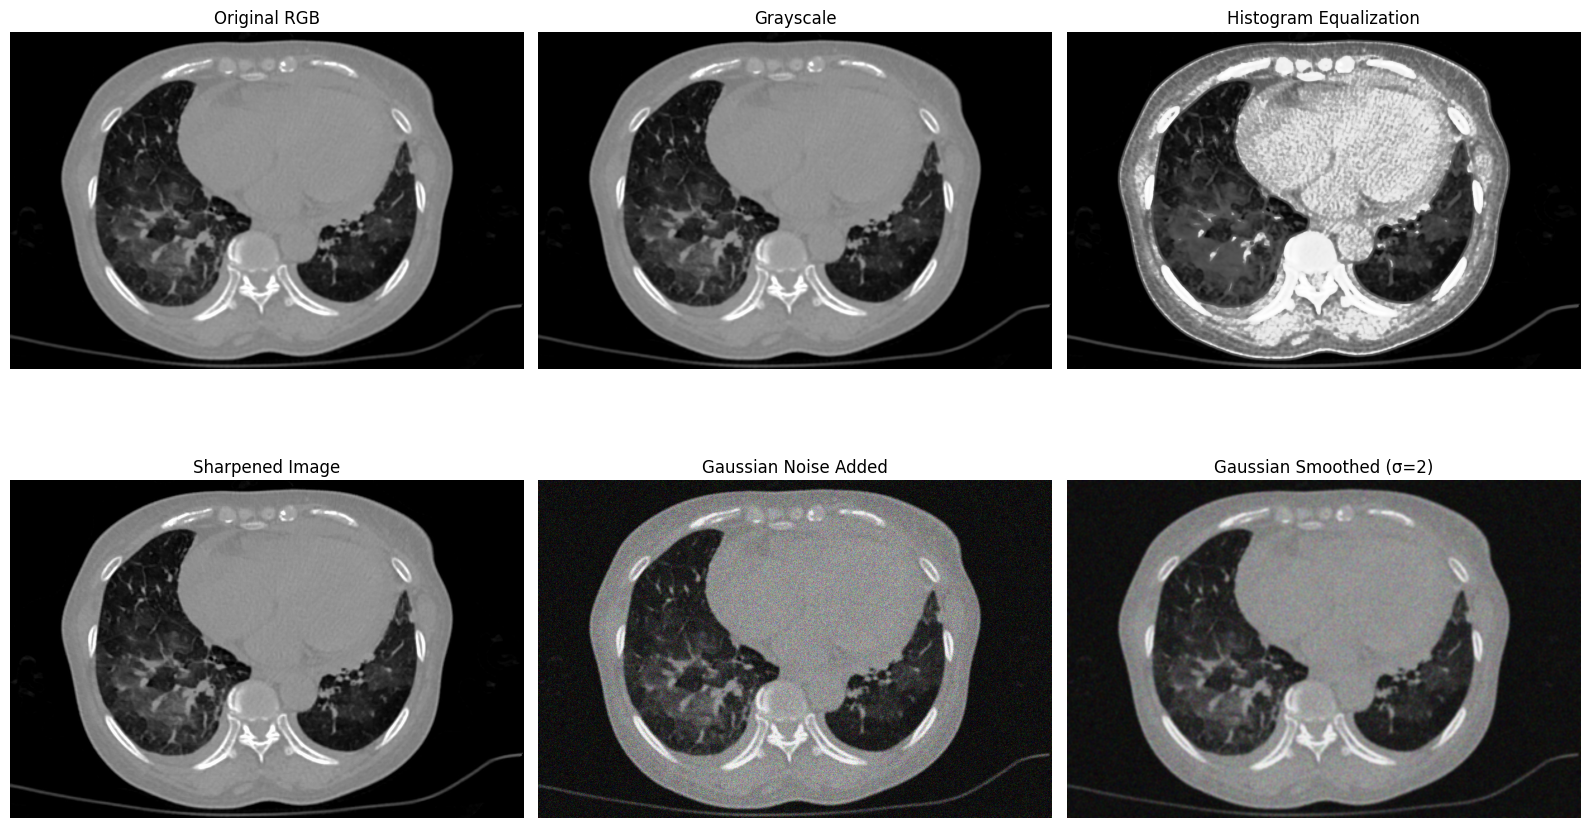

In [4]:
# Plot using classic subplot notation
plt.figure(figsize=(16, 10))

plt.subplot(231)
plt.imshow(image)
plt.title('Original RGB')
plt.axis('off')

plt.subplot(232)
plt.imshow(image_gray, cmap='gray')
plt.title('Grayscale')
plt.axis('off')

plt.subplot(233)
plt.imshow(equalized, cmap='gray')
plt.title('Histogram Equalization')
plt.axis('off')

plt.subplot(234)
plt.imshow(sharpened)
plt.title('Sharpened Image')
plt.axis('off')

plt.subplot(235)
plt.imshow(noise_image)
plt.title('Gaussian Noise Added')
plt.axis('off')

plt.subplot(236)
plt.imshow(smoothed_image)
plt.title(f'Gaussian Smoothed (σ={sigma})')
plt.axis('off')

plt.tight_layout()
plt.show()


Mask shape: (881, 1339)


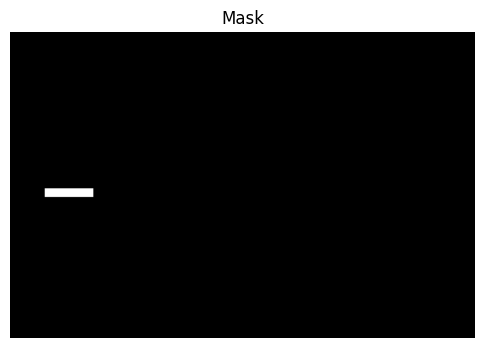

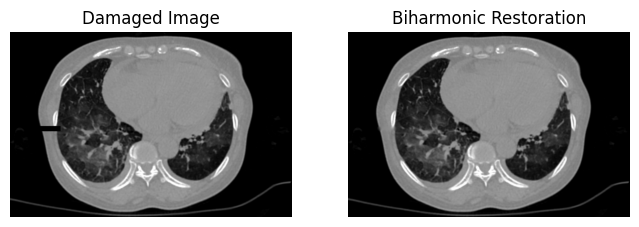

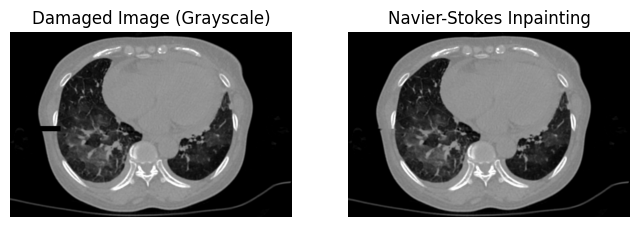

In [ ]:
# 2. Image Restoration
mask = np.zeros(image.shape[:2], dtype=np.uint8)
mask[450:475, 100:240] = 1  # Region to inpaint
print("Mask shape:", mask.shape)

plt.figure(figsize=(6,4))
plt.axis('off')
plt.title("Mask")
plt.imshow(mask, cmap='gray')
plt.show()

# 2. Create damaged image by setting masked pixels to 0 (black)
damaged_image = image.copy()
damaged_image[mask == 1] = 0

plt.figure(figsize=(8,4))
plt.subplot(1,2,1)
plt.axis('off')
plt.title("Damaged Image")
plt.imshow(damaged_image)

# 3. Biharmonic inpainting expects grayscale float image [0,1]
# Convert damaged image to grayscale float [0,1]
damaged_gray = cv2.cvtColor(damaged_image, cv2.COLOR_RGB2GRAY) / 255.0

restored_biharmonic = inpaint.inpaint_biharmonic(damaged_gray, mask)

plt.subplot(1,2,2)
plt.axis('off')
plt.title("Biharmonic Restoration")
plt.imshow(restored_biharmonic, cmap='gray')
plt.show()

# 4. Navier-Stokes inpainting (OpenCV) - input must be uint8 grayscale or color
damaged_gray_uint8 = (damaged_gray * 255).astype(np.uint8)
mask_255 = (mask * 255).astype(np.uint8)

inpainted_ns = cv2.inpaint(damaged_gray_uint8, mask_255, inpaintRadius=3, flags=cv2.INPAINT_NS)

plt.figure(figsize=(8,4))
plt.subplot(1,2,1)
plt.axis('off')
plt.title("Damaged Image (Grayscale)")
plt.imshow(damaged_gray, cmap='gray')

plt.subplot(1,2,2)
plt.axis('off')
plt.title("Navier-Stokes Inpainting")
plt.imshow(inpainted_ns, cmap='gray')
plt.show()

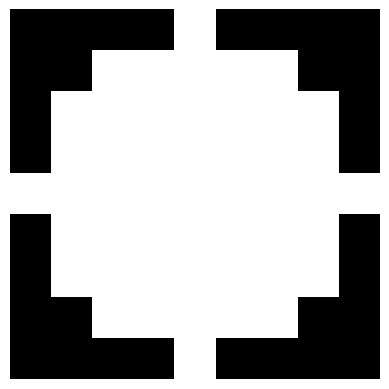

In [9]:
# 3. Morphological Operation 

#Morphological Operation
shape_disk = morphology.disk(4)

plt.axis('off')
plt.imshow(shape_disk, cmap = 'gray')

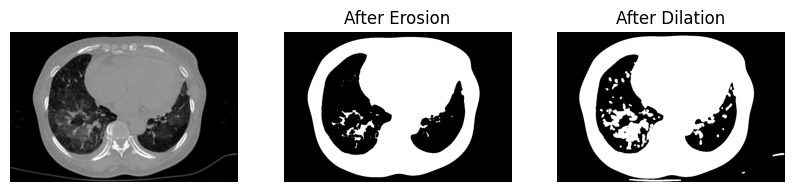

In [12]:
image_morph = imread('unenhanced.jpg')
image_morph = image_morph[:, :, :3]

gray = rgb2gray(image_morph)
thresh = threshold_otsu(gray)
binary = gray > thresh
erosion = morphology.binary_erosion(binary, footprint=shape_disk)
dilation = morphology.binary_dilation(binary, footprint=shape_disk)

plt.figure(figsize=(10,10))
plt.subplot(1,3,1)
plt.axis('off')
plt.imshow(image_morph, cmap ='gray')

plt.subplot(1,3,2)
plt.axis('off')
plt.title('After Erosion')
plt.imshow(erosion, cmap = 'gray')

plt.subplot(1,3,3)
plt.axis('off')
plt.title('After Dilation')
plt.imshow(dilation, cmap = 'gray')

e:\Image_Processing\venv\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
e:\Image_Processing\venv\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=DeepLabV3_ResNet101_Weights.COCO_WITH_VOC_LABELS_V1`. You can also use `weights=DeepLabV3_ResNet101_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/deeplabv3_resnet101_coco-586e9e4e.pth" to C:\Users\User/.cache\torch\hub\checkpoints\deeplabv3_resnet101_coco-586e9e4e.pth


100%|██████████| 233M/233M [00:36<00:00, 6.62MB/s] 


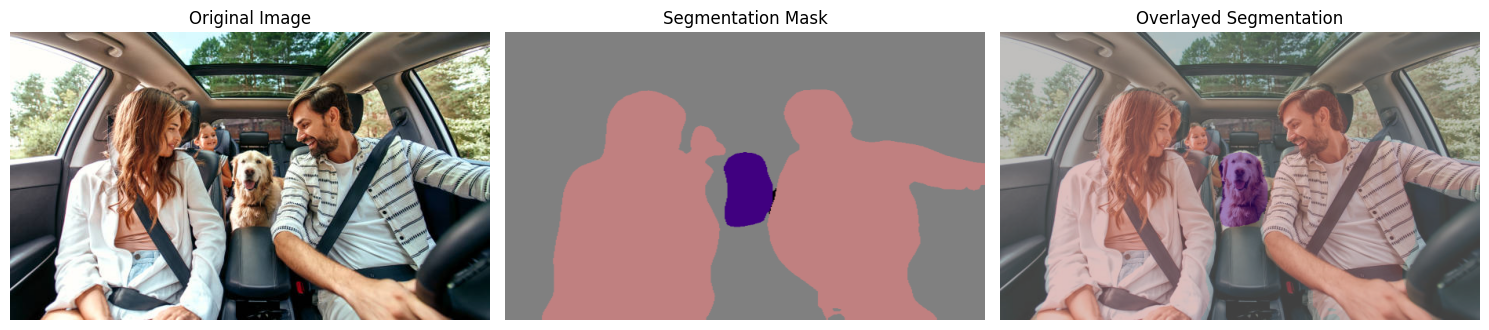

In [ ]:
# 4. Image Segmentation

# Load the pre-trained DeepLabV3 model
model = deeplabv3_resnet101(pretrained=True)
model.eval()

# Load and preprocess image
img_path = 'Unsegmented.jpg' 
img_bgr = cv2.imread(img_path)
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

# Define transforms: resize, to tensor, normalize
transform = T.Compose([
    T.ToPILImage(),
    T.Resize((520, 520)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225])
])

input_tensor = transform(img_rgb).unsqueeze(0)  # Add batch dimension

# Run inference
with torch.no_grad():
    output = model(input_tensor)['out'][0]
    seg_map = output.argmax(0).byte().cpu().numpy()

# Generate a color palette for 21 classes (Pascal VOC)
def decode_segmap(seg, n_classes=21):
    label_colors = np.array([
        (0, 0, 0),       # 0=background
        (128, 0, 0),     # 1=aeroplane
        (0, 128, 0),     # 2=bicycle
        (128, 128, 0),   # 3=bird
        (0, 0, 128),     # 4=boat
        (128, 0, 128),   # 5=bottle
        (0, 128, 128),   # 6=bus
        (128, 128, 128), # 7=car
        (64, 0, 0),      # 8=cat
        (192, 0, 0),     # 9=chair
        (64, 128, 0),    # 10=cow
        (192, 128, 0),   # 11=dining table
        (64, 0, 128),    # 12=dog
        (192, 0, 128),   # 13=horse
        (64, 128, 128),  # 14=motorbike
        (192, 128, 128), # 15=person
        (0, 64, 0),      # 16=potted plant
        (128, 64, 0),    # 17=sheep
        (0, 192, 0),     # 18=sofa
        (128, 192, 0),   # 19=train
        (0, 64, 128)     # 20=tv/monitor
    ])
    r = np.zeros_like(seg).astype(np.uint8)
    g = np.zeros_like(seg).astype(np.uint8)
    b = np.zeros_like(seg).astype(np.uint8)
    
    for l in range(0, n_classes):
        idx = seg == l
        r[idx] = label_colors[l, 0]
        g[idx] = label_colors[l, 1]
        b[idx] = label_colors[l, 2]

    return np.stack([r, g, b], axis=2)

seg_colored = decode_segmap(seg_map)

# Resize segmentation mask back to original size
seg_colored_resized = cv2.resize(seg_colored, (img_rgb.shape[1], img_rgb.shape[0]))

# Overlay mask on original image (50% transparent)
overlay = cv2.addWeighted(img_rgb, 0.5, seg_colored_resized, 0.5, 0)

# Plot
plt.figure(figsize=(15, 6))

plt.subplot(131)
plt.imshow(img_rgb)
plt.title("Original Image")
plt.axis('off')

plt.subplot(132)
plt.imshow(seg_colored_resized)
plt.title("Segmentation Mask")
plt.axis('off')

plt.subplot(133)
plt.imshow(overlay)
plt.title("Overlayed Segmentation")
plt.axis('off')

plt.tight_layout()
plt.show()

PRO TIP  Replace 'model=yolov5s.pt' with new 'model=yolov5su.pt'.
YOLOv5 'u' models are trained with https://github.com/ultralytics/ultralytics and feature improved performance vs standard YOLOv5 models trained with https://github.com/ultralytics/yolov5.


0: 384x640 2 persons, 1 car, 1 dog, 1 handbag, 102.6ms
Speed: 4.5ms preprocess, 102.6ms inference, 4.7ms postprocess per image at shape (1, 3, 384, 640)
Detected person with confidence 0.92
Detected dog with confidence 0.81
Detected car with confidence 0.61
Detected person with confidence 0.56
Detected handbag with confidence 0.33


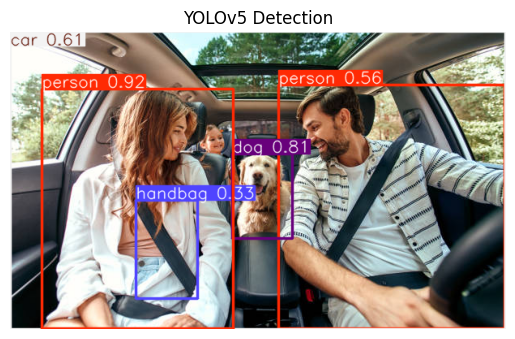

In [ ]:
# 5. Image Recognition
# Load pre-trained YOLOv5s model
model = YOLO("yolov5s.pt")

# Load and preprocess image
img_path = "Unsegmented.jpg"
image = cv2.imread(img_path)
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# 1. Run inference
results = model(image_rgb)

# 2. PASTE HERE: Analyze detected objects
for box in results[0].boxes:
    cls_id = int(box.cls[0])           # Class index (e.g., 0 = person)
    conf = float(box.conf[0])          # Confidence score
    label = model.names[cls_id]        # Class label (e.g., "person")
    print(f"Detected {label} with confidence {conf:.2f}")

# 3. Plot annotated result
annotated_img = results[0].plot()
plt.imshow(annotated_img)
plt.title("YOLOv5 Detection")
plt.axis('off')
plt.show()
